In [1]:
# import all necessary libraries
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
import random
from sklearn.metrics import confusion_matrix
import seaborn as sns
import math
from sklearn.metrics import classification_report
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from matplotlib.image import imread
import os
import shutil
from sklearn.model_selection import train_test_split
import urllib.request
from PIL import Image
import requests
from io import BytesIO
import numpy as np

In [2]:
df_GT = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/Data/ISIC_2020_Training_GroundTruth_v2.csv')
df_GT

,image_name,patient_id,lesion_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target
0,ISIC_2637011,IP_7279968,IL_7972535,male,45.0,head/neck,unknown,benign,0
1,ISIC_0015719,IP_3075186,IL_4649854,female,45.0,upper extremity,unknown,benign,0
2,ISIC_0052212,IP_2842074,IL_9087444,female,50.0,lower extremity,nevus,benign,0
3,ISIC_0068279,IP_6890425,IL_4255399,female,45.0,head/neck,unknown,benign,0
4,ISIC_0074268,IP_8723313,IL_6898037,female,55.0,upper extremity,unknown,benign,0
...,...,...,...,...,...,...,...,...,...
33121,ISIC_9999134,IP_6526534,IL_2076932,male,50.0,torso,unknown,benign,0
33122,ISIC_9999320,IP_3650745,IL_6891604,male,65.0,torso,unknown,benign,0
33123,ISIC_9999515,IP_2026598,IL_6364820,male,20.0,lower extremity,unknown,benign,0
33124,ISIC_9999666,IP_7702038,IL_6048457,male,50.0,lower extremity,unknown,benign,0


In [3]:
# Fix: Use a list of column names (double brackets) to select multiple columns
name = df_GT[["image_name", "benign_malignant"]]
name.head()

,image_name,benign_malignant
0,ISIC_2637011,benign
1,ISIC_0015719,benign
2,ISIC_0052212,benign
3,ISIC_0068279,benign
4,ISIC_0074268,benign


In [4]:
training_file = "/content/drive/MyDrive/Colab_Notebooks/Data/skin_training_data.zip"

In [5]:
testing_file = "/content/drive/MyDrive/Colab_Notebooks/Data/skin_test_data.zip"

In [6]:
val_file = "/content/drive/MyDrive/Colab_Notebooks/Data/skin_val_data.zip"

In [7]:
import zipfile
import os
import shutil

def download_and_unzip(url, target_dir):
    organized_path = os.path.join(target_dir, 'organized_data')
    benign_path = os.path.join(organized_path, 'benign')
    malignant_path = os.path.join(organized_path, 'malignant')

    # 1. Immediate Cache Check
    if os.path.exists(benign_path) and os.path.exists(malignant_path):
        b_count = len(os.listdir(benign_path))
        m_count = len(os.listdir(malignant_path))
        if b_count > 0 or m_count > 0:
            print(f"Cache Found: Data already exists in {organized_path}")
            print(f"Total Benign: {b_count}")
            print(f"Total Malignant: {m_count}")
            return

    # 2. Define extraction path if cache fails
    extract_path = os.path.join(target_dir, 'extracted_temp')
    os.makedirs(extract_path, exist_ok=True)

    # 3. Unzip the file
    with zipfile.ZipFile(url, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
        print(f"Extracted zip to {extract_path}")

    # 4. Create class directories
    os.makedirs(benign_path, exist_ok=True)
    os.makedirs(malignant_path, exist_ok=True)

    # 5. Create lookup map
    label_map = dict(zip(name['image_name'], name['benign_malignant']))

    # 6. Sort images
    count = 0
    for root, dirs, files in os.walk(extract_path):
        for file in files:
            if file.lower().endswith('.jpg'):
                img_id = os.path.splitext(file)[0]
                if img_id in label_map:
                    label = label_map[img_id]
                    src = os.path.join(root, file)
                    dst = os.path.join(organized_path, label, file)
                    if not os.path.exists(dst):
                        shutil.copy(src, dst)
                        count += 1

    print(f"Organized {count} new images.")
    print(f"Total Benign: {len(os.listdir(benign_path))}")
    print(f"Total Malignant: {len(os.listdir(malignant_path))}")

In [8]:
train_target = "/content/drive/MyDrive/Colab_Notebooks/Data/Skin_train"

In [9]:
download_and_unzip(training_file,train_target)

Cache Found: Data already exists in /content/drive/MyDrive/Colab_Notebooks/Data/Skin_train/organized_data
Total Benign: 2129
Total Malignant: 31


In [10]:
test_target = "/content/drive/MyDrive/Colab_Notebooks/Data/Skin_test"

In [11]:
download_and_unzip(testing_file,test_target)

Cache Found: Data already exists in /content/drive/MyDrive/Colab_Notebooks/Data/Skin_test/organized_data
Total Benign: 593
Total Malignant: 7


In [12]:
val_target = "/content/drive/MyDrive/Colab_Notebooks/Data/Skin_val"

In [13]:
download_and_unzip(val_file,val_target)

Cache Found: Data already exists in /content/drive/MyDrive/Colab_Notebooks/Data/Skin_val/organized_data
Total Benign: 238
Total Malignant: 2


In [14]:
train_dataset_path = "/content/drive/MyDrive/Colab_Notebooks/Data/Skin_train/organized_data"

In [15]:
test_dataset_path = "/content/drive/MyDrive/Colab_Notebooks/Data/Skin_test/organized_data"

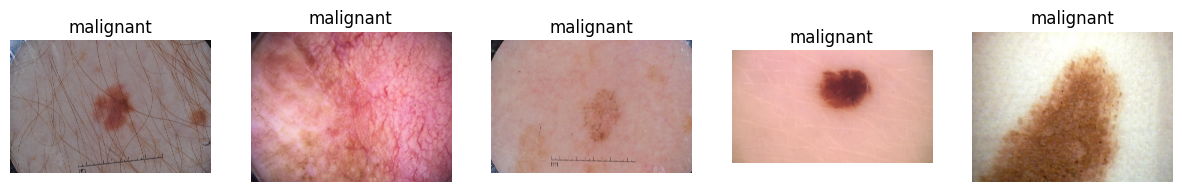

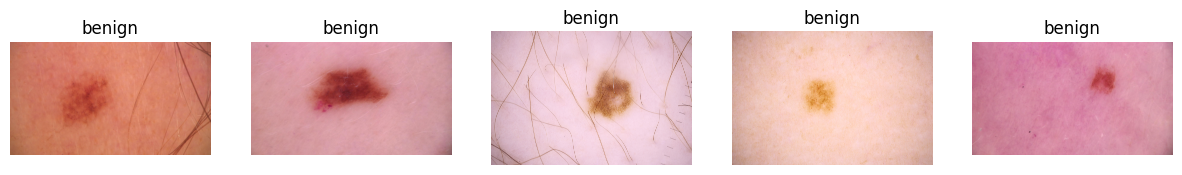

In [16]:
#function to display image from our dataset
def display_sample_images(class_name, dataset_path):
    folder_path = os.path.join(dataset_path, class_name)
    images = random.sample(os.listdir(folder_path), 5)
    plt.figure(figsize=(15, 5))
    for idx, img_name in enumerate(images):
        img = imread(os.path.join(folder_path, img_name))
        plt.subplot(1, 5, idx+1)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis('off')
    plt.show()

display_sample_images('malignant',train_dataset_path)
display_sample_images('benign',train_dataset_path)


In [17]:
img_height, img_width = 150, 150
batch_size = 32

In [18]:
train_datagen = ImageDataGenerator(
    rescale=1./255,          # Normalize pixel values
)

In [19]:
train_datagen_aug = ImageDataGenerator(
    rescale=1./255,          # Normalize pixel values
    shear_range=0.2,         # Shear transformation
    zoom_range=0.2,          # Zoom
    horizontal_flip=True,    # Horizontal flip
)

In [20]:
test_datagen_aug = ImageDataGenerator(
    rescale=1./255,          # Normalize pixel values
    shear_range=0.2,         # Shear transformation
    zoom_range=0.2,          # Zoom
    horizontal_flip=True,    # Horizontal flip
)

In [21]:
train_generator = train_datagen_aug.flow_from_directory(
    train_dataset_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training'        # Set as training data
)

Found 2160 images belonging to 2 classes.


In [22]:
test_generator = test_datagen_aug.flow_from_directory(
    test_dataset_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

Found 600 images belonging to 2 classes.


In [23]:
model = Sequential([
    Conv2D(32,(3,3), activation='relu', input_shape=(img_height, img_width, 3)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(512, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,034,177 (72.61 MB)

 Trainable params: 19,034,177 (72.61 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 1. Define Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_skin_model.keras', monitor='val_accuracy', save_best_only=True)

# 2. Train the model
print("Starting training...")
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    validation_data=test_generator,
    validation_steps=test_generator.samples // batch_size,
    epochs=20,
    callbacks=[early_stop, checkpoint]
)

print("Training Complete. Best model saved as 'best_skin_model.keras'")

Starting training...
Epoch 1/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 447s 7s/step - accuracy: 0.9854 - loss: 0.1242 - val_accuracy: 1.0000 - val_loss: 0.0013
Epoch 2/20
 1/67 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 1.0000 - loss: 0.0013

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


67/67 ━━━━━━━━━━━━━━━━━━━━ 57s 858ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 1.0000 - val_loss: 5.9630e-04
Epoch 3/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 239s 4s/step - accuracy: 0.9854 - loss: 0.0820 - val_accuracy: 1.0000 - val_loss: 0.0135
Epoch 4/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 45s 677ms/step - accuracy: 1.0000 - loss: 0.0127 - val_accuracy: 1.0000 - val_loss: 0.0155
Epoch 5/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 221s 3s/step - accuracy: 0.9859 - loss: 0.0819 - val_accuracy: 1.0000 - val_loss: 0.0076
Epoch 6/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 50s 760ms/step - accuracy: 0.9688 - loss: 0.1437 - val_accuracy: 1.0000 - val_loss: 0.0043
Epoch 7/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 228s 3s/step - accuracy: 0.9854 - loss: 0.0829 - val_accuracy: 1.0000 - val_loss: 0.0092
Training Complete. Best model saved as 'best_skin_model.keras'


19/19 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step
Classification Report:
              precision    recall  f1-score   support

      benign       0.99      1.00      0.99       593
   malignant       0.00      0.00      0.00         7

    accuracy                           0.99       600
   macro avg       0.49      0.50      0.50       600
weighted avg       0.98      0.99      0.98       600



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


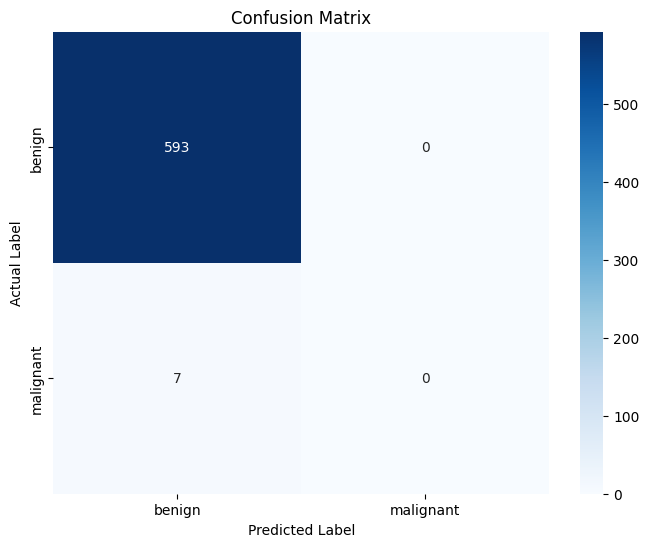

In [25]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Reset generator and predict
test_generator.reset()
predictions = model.predict(test_generator)
y_pred = (predictions > 0.5).astype(int)
y_true = test_generator.classes

# 2. Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=['benign', 'malignant']))

# 3. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['benign', 'malignant'], yticklabels=['benign', 'malignant'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
import pandas as pd
import os

# 1. Identify images actually present on disk
available_images = []
for label in ['benign', 'malignant']:
    folder = os.path.join(train_dataset_path, label)
    if os.path.exists(folder):
        for img_file in os.listdir(folder):
            if img_file.endswith('.jpg'):
                available_images.append({'image_name': os.path.splitext(img_file)[0], 'benign_malignant': label, 'filename': os.path.join(label, img_file)})

df_available = pd.DataFrame(available_images)

# 2. Sample from available images
m_count = len(df_available[df_available['benign_malignant'] == 'malignant'])
b_samples = df_available[df_available['benign_malignant'] == 'benign'].sample(min(31, m_count), random_state=42)
m_samples = df_available[df_available['benign_malignant'] == 'malignant'].sample(min(31, m_count), random_state=42)

balanced_df = pd.concat([b_samples, m_samples])

print(f"Created balanced dataset with {len(balanced_df)} physically verified images.")

# 3. Create the generators with class_mode='input' for autoencoding
autoenc_datagen = ImageDataGenerator(rescale=1./255)

autoenc_generator = autoenc_datagen.flow_from_dataframe(
    dataframe=balanced_df,
    directory=train_dataset_path,
    x_col='filename',
    y_col=None,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='input',
    shuffle=True
)

# Fix: Create a validation generator for the autoencoder specifically
# This ensures the validation target is the image, not a class label
autoenc_val_generator = autoenc_datagen.flow_from_directory(
    test_dataset_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='input',
    shuffle=False
)

print(f"Total training images: {autoenc_generator.samples}")
print(f"Total validation images: {autoenc_val_generator.samples}")

In [27]:
import keras
from keras import layers

input_img = keras.Input(shape=(img_height, img_width, 3))

# Encoder - Deepened with more filters and an extra layer
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(8, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(8, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

# Decoder - Mirroring the deepened encoder
x = layers.Conv2D(8, (3, 3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(8, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)

# Match input shape (150, 150)
x = layers.CenterCrop(img_height, img_width)(x)
decoded = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder = keras.Model(input_img, decoded)
# Added accuracy to metrics
autoencoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 75, 75, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 38, 38, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 38, 38, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 19, 19, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 19, 19, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 10, 10, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 10, 10, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 20, 20, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 20, 20, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 40, 40, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 40, 40, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 80, 80, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 80, 80, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 160, 160, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ center_crop (CenterCrop)        │ (None, 150, 150, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 150, 150, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,107 (59.01 KB)

 Trainable params: 15,107 (59.01 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
# 1. Define Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# 2. Train the model using the corrected validation generator
print("Starting deepened autoencoder training...")
history_auto = autoencoder.fit(
    autoenc_generator,
    steps_per_epoch=max(1, autoenc_generator.samples // batch_size),
    epochs=50,
    validation_data=autoenc_val_generator,
    validation_steps=max(1, autoenc_val_generator.samples // batch_size),
    callbacks=[early_stop]
)

print("Autoencoder training complete.")

Starting deepened autoencoder training...
Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 49s 49s/step - accuracy: 0.9185 - loss: 0.6864 - val_accuracy: 0.9295 - val_loss: 0.6785
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 42s 42s/step - accuracy: 0.9149 - loss: 0.6824 - val_accuracy: 0.9331 - val_loss: 0.6700
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 95s 95s/step - accuracy: 0.9053 - loss: 0.6744 - val_accuracy: 0.9371 - val_loss: 0.6581
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 45s 45s/step - accuracy: 0.9387 - loss: 0.6699 - val_accuracy: 0.9393 - val_loss: 0.6423
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 79s 79s/step - accuracy: 0.9225 - loss: 0.6575 - val_accuracy: 0.9414 - val_loss: 0.6231
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 46s 46s/step - accuracy: 0.9318 - loss: 0.6425 - val_accuracy: 0.9579 - val_loss: 0.6039
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 44s 44s/step - accuracy: 0.9540 - loss: 0.6279 - val_accuracy: 0.9675 - val_loss: 0.5909
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 43s 43s/step - accuracy: 0.9440 - loss: 0.6382 

Found 600 images belonging to 2 classes.
19/19 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step
Using Refined Threshold: 0.0423
              precision    recall  f1-score   support

      benign       0.99      0.88      0.93       593
   malignant       0.04      0.43      0.08         7

    accuracy                           0.88       600
   macro avg       0.52      0.66      0.51       600
weighted avg       0.98      0.88      0.92       600



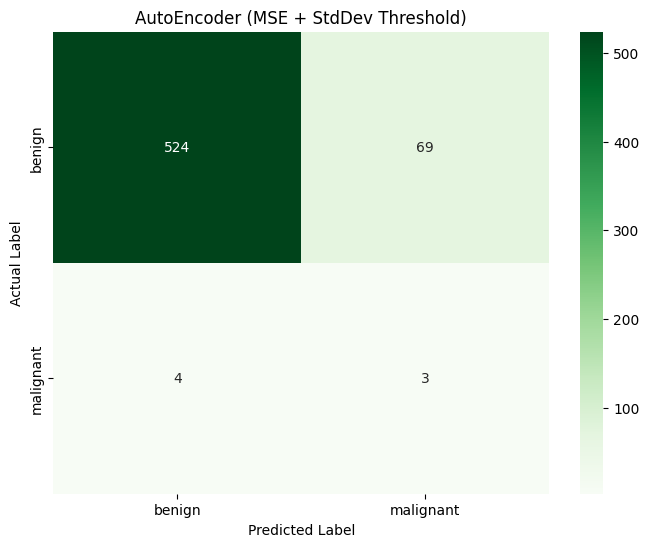

In [30]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Re-ensure all global variables are set if session was reset
img_height, img_width = 150, 150
batch_size = 32
test_dataset_path = "/content/drive/MyDrive/Colab_Notebooks/Data/Skin_test/organized_data"
test_datagen_aug = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen_aug.flow_from_directory(
    test_dataset_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

# 1. Reset generator and predict
test_generator.reset()
predictions = autoencoder.predict(test_generator)

# 2. Re-extract original images to calculate MSE
test_generator.reset()
all_x = []
for i in range(len(test_generator)):
    batch_x, _ = test_generator[i]
    all_x.append(batch_x)
x_test_all = np.vstack(all_x)

# 3. Calculate MSE
mse = np.mean(np.power(x_test_all - predictions, 2), axis=(1, 2, 3))

# 4. Refined Thresholding: Mean + 1 Standard Deviation
threshold = np.mean(mse) + np.std(mse)
y_pred = (mse > threshold).astype(int)
y_true = test_generator.classes

# 5. Results
print(f"Using Refined Threshold: {threshold:.4f}")
print(classification_report(y_true, y_pred, target_names=['benign', 'malignant']))

# 6. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['benign', 'malignant'], yticklabels=['benign', 'malignant'])
plt.title('AutoEncoder (MSE + StdDev Threshold)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()